# Hypothesis scoring
## positive vs negative Comparison Experiment

This notebook contains the code for the positive vs negative comparison experiment (PubTator3 vs PubMed) used in this paper.

### Overview

This experiment compares the effectiveness of PubTator3 and PubMed APIs for validating biological hypotheses:
- **Positive Group**: Viewpoints that should be validated (true positives)
- **Negative Group**: Viewpoints that might be unseen
- **Comparison**: positive vs negative comparison

### Key Metrics
- LLM-validated viewpoint rate
- Precision, Recall, F1-score
- Statistical significance testing

## Proteins with top ranked hypothesis score.
The top ranked hypothesis with ON(overall Novelty), OP(overall Plausbility), OS(Overall score) are demonstrated in barplot.


## 1. Data Loading and Setup

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from collections import OrderedDict
import os

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure matplotlib for better quality
%config InlineBackend.figure_format = 'svg'
fs_base = 20
plt.rcParams.update({
    'font.size': fs_base-2,
    'axes.titlesize': fs_base+2,
    'axes.labelsize': fs_base,
    'xtick.labelsize': fs_base-2,
    'ytick.labelsize': fs_base-2,
    'legend.fontsize': fs_base-2,
    'figure.titlesize': fs_base+2
})

In [3]:
# Load positive group data
with open('../examples/Plausibility/2020/positive/evidence_results_pubmed.json', 'r') as f:
    pubmed_positive = json.load(f)
with open('../examples/Plausibility/2020/positive/evidence_results_pubtator3.json', 'r') as f:
    pubtator3_positive = json.load(f)

# Load negative group data
with open('../examples/Plausibility/2020/negative/evidence_results_pubmed.json', 'r') as f:
    pubmed_negative = json.load(f)
with open('../examples/Plausibility/2020/negative/evidence_results_pubtator3.json', 'r') as f:
    pubtator3_negative = json.load(f)

print("Data loaded successfully!")
print(f"Positive PubMed viewpoints: {sum(len(vps) for vps in pubmed_positive.values())}")
print(f"Positive PubTator3 viewpoints: {sum(len(vps) for vps in pubtator3_positive.values())}")
print(f"Negative PubMed viewpoints: {sum(len(vps) for vps in pubmed_negative.values())}")
print(f"Negative PubTator3 viewpoints: {sum(len(vps) for vps in pubtator3_negative.values())}")

Data loaded successfully!
Positive PubMed viewpoints: 135
Positive PubTator3 viewpoints: 135
Negative PubMed viewpoints: 77
Negative PubTator3 viewpoints: 77


## 2. Helper Functions

In [4]:
def extract_evidence(y_dict):
    """Extract evidence predictions from viewpoint dictionaries"""
    y_true = []
    y_pred = []
    for file, vps in y_dict.items():
        for vp in vps:
            # True label is always True for positive group
            y_true.append(True)
            # Predicted label is the 'evidence' field
            y_pred.append(bool(vp.get('evidence', False)))
    return y_true, y_pred

def get_evidence_dict_sorted(data):
    """Convert data to ordered dict {viewpoint_id: evidence} sorted by start_node first letter"""
    temp = []
    for file, items in data.items():
        for idx, item in enumerate(items):
            viewpoint_id = f"{file}#{idx}"
            evidence = item.get('evidence', False)
            start_node = item.get('start_node', '')
            first_char = start_node[0] if start_node else ''
            temp.append((first_char, viewpoint_id, evidence))
    
    temp_sorted = sorted(temp, key=lambda x: x[0])
    evidence_dict = OrderedDict()
    for _, viewpoint_id, evidence in temp_sorted:
        evidence_dict[viewpoint_id] = evidence
    return evidence_dict

def print_metrics(name, y_true, y_pred):
    """Print confusion matrix and metrics"""
    cm = confusion_matrix(y_true, y_pred, labels=[True, False])
    precision = precision_score(y_true, y_pred, pos_label=True)
    recall = recall_score(y_true, y_pred, pos_label=True)
    f1 = f1_score(y_true, y_pred, pos_label=True)
    
    print(f"\n{name} Confusion Matrix:")
    print(cm)
    print(f"{name} Precision: {precision:.4f}")
    print(f"{name} Recall: {recall:.4f}")
    print(f"{name} F1-score: {f1:.4f}")
    
    return cm, precision, recall, f1

def print_true_ratio_per_group(name, y_dict):
    """Print evidence rate per group and overall"""
    print(f"\n{name} evidence == True ratio per group:")
    true_ratio = {}
    total_true = 0
    total_count = 0
    
    for file, vps in y_dict.items():
        total = len(vps)
        true_count = sum(1 for vp in vps if vp.get('evidence', False))
        ratio = true_count / total if total > 0 else 0
        pmid = os.path.basename(file)
        print(f"  {pmid}: {true_count}/{total} = {ratio:.4f}")
        true_ratio[pmid] = ratio
        total_true += true_count
        total_count += total
    
    overall_ratio = total_true / total_count if total_count > 0 else 0
    print(f"\n{name} overall evidence == True ratio: {total_true}/{total_count} = {overall_ratio:.4f}")
    
    return true_ratio, overall_ratio

def get_pmid_rates(evidence_dict):
    """Get per-PMID evidence rates for statistical analysis"""
    pmid_to_evidence = {}
    for viewpoint_id, evidence in evidence_dict.items():
        pmid = viewpoint_id.split('#')[0]
        pmid_to_evidence.setdefault(pmid, []).append(bool(evidence))
    pmid_means = [np.mean(evs) for evs in pmid_to_evidence.values()]
    return pmid_means

## 3. Positive Group Analysis

In [5]:
# Extract evidence predictions for positive group
y_true_pubmed, y_pred_pubmed = extract_evidence(pubmed_positive)
y_true_pubtator3, y_pred_pubtator3 = extract_evidence(pubtator3_positive)

# Calculate metrics
pubmed_cm, pubmed_precision, pubmed_recall, pubmed_f1 = print_metrics("PubMed", y_true_pubmed, y_pred_pubmed)
pubtator_cm, pubtator_precision, pubtator_recall, pubtator_f1 = print_metrics("PubTator3", y_true_pubtator3, y_pred_pubtator3)

# Print per-group ratios
pubmed_true_ratio, pubmed_overall_ratio = print_true_ratio_per_group("PubMed", pubmed_positive)
pubtator_true_ratio, pubtator_overall_ratio = print_true_ratio_per_group("PubTator3", pubtator3_positive)


PubMed Confusion Matrix:
[[122  13]
 [  0   0]]
PubMed Precision: 1.0000
PubMed Recall: 0.9037
PubMed F1-score: 0.9494

PubTator3 Confusion Matrix:
[[120  15]
 [  0   0]]
PubTator3 Precision: 1.0000
PubTator3 Recall: 0.8889
PubTator3 F1-score: 0.9412

PubMed evidence == True ratio per group:
  32192216: 8/12 = 0.6667
  32295598: 24/30 = 0.8000
  32664576: 11/11 = 1.0000
  32849585: 11/12 = 0.9167
  33643816: 24/24 = 1.0000
  32111216: 5/5 = 1.0000
  32143309: 10/10 = 1.0000
  32492896: 9/10 = 0.9000
  32606456: 10/10 = 1.0000
  32631382: 10/11 = 0.9091

PubMed overall evidence == True ratio: 122/135 = 0.9037

PubTator3 evidence == True ratio per group:
  32192216: 8/12 = 0.6667
  32295598: 23/30 = 0.7667
  32664576: 11/11 = 1.0000
  32849585: 11/12 = 0.9167
  33643816: 23/24 = 0.9583
  32111216: 5/5 = 1.0000
  32143309: 10/10 = 1.0000
  32492896: 9/10 = 0.9000
  32606456: 10/10 = 1.0000
  32631382: 10/11 = 0.9091

PubTator3 overall evidence == True ratio: 120/135 = 0.8889


## 4. Negative Group Analysis

In [12]:
# Extract evidence predictions for negative group
y_true_pubmed_neg, _ = extract_evidence(pubmed_negative)
y_true_pubtator3_neg, _ = extract_evidence(pubtator3_negative)

# Print per-group ratios for negative group
pubmed_true_ratio_neg, pubmed_overall_ratio_neg = print_true_ratio_per_group("PubMed (Negative)", pubmed_negative)
pubtator_true_ratio_neg, pubtator_overall_ratio_neg = print_true_ratio_per_group("PubTator3 (Negative)", pubtator3_negative)


PubMed (Negative) evidence == True ratio per group:
  32664576_8: 7/8 = 0.8750
  32606456_8: 3/7 = 0.4286
  32192216_8: 7/10 = 0.7000
  32295598_8: 9/13 = 0.6923
  32631382_8: 9/11 = 0.8182
  32111216_8: 5/6 = 0.8333
  32849585_8: 3/5 = 0.6000
  32143309_8: 3/6 = 0.5000
  32492896_8: 5/5 = 1.0000
  33643816_8: 2/6 = 0.3333

PubMed (Negative) overall evidence == True ratio: 53/77 = 0.6883

PubTator3 (Negative) evidence == True ratio per group:
  32664576_8: 8/8 = 1.0000
  32606456_8: 2/7 = 0.2857
  32192216_8: 4/10 = 0.4000
  32295598_8: 11/13 = 0.8462
  32631382_8: 9/11 = 0.8182
  32111216_8: 6/6 = 1.0000
  32849585_8: 3/5 = 0.6000
  32143309_8: 4/6 = 0.6667
  32492896_8: 3/5 = 0.6000
  33643816_8: 4/6 = 0.6667

PubTator3 (Negative) overall evidence == True ratio: 54/77 = 0.7013


## 5. Cross-API Comparison Analysis

In [7]:
# Get sorted evidence dictionaries
pubmed_evidence_dict = get_evidence_dict_sorted(pubmed_negative)
pubtator3_evidence_dict = get_evidence_dict_sorted(pubtator3_negative)

# Find common viewpoints
common_viewpoints = set(pubmed_evidence_dict.keys()) & set(pubtator3_evidence_dict.keys())

# Find viewpoints with different evidence answers
diff_viewpoints = []
for vid in common_viewpoints:
    if pubmed_evidence_dict[vid] != pubtator3_evidence_dict[vid]:
        diff_viewpoints.append(vid)

print(f"PubMed negative and PubTator3 negative evidence answer different viewpoints: {len(diff_viewpoints)}")
if diff_viewpoints:
    print("Different viewpoint examples:")
    for vid in sorted(diff_viewpoints, reverse=False):
        print(f"{vid}: PubMed={pubmed_evidence_dict[vid]}, PubTator3={pubtator3_evidence_dict[vid]}")

PubMed negative and PubTator3 negative evidence answer different viewpoints: 15
Different viewpoint examples:
/data/AI_scientists/Plausibility/2020/negative/32111216_8#5: PubMed=False, PubTator3=True
/data/AI_scientists/Plausibility/2020/negative/32143309_8#1: PubMed=False, PubTator3=True
/data/AI_scientists/Plausibility/2020/negative/32192216_8#1: PubMed=True, PubTator3=False
/data/AI_scientists/Plausibility/2020/negative/32192216_8#6: PubMed=True, PubTator3=False
/data/AI_scientists/Plausibility/2020/negative/32192216_8#8: PubMed=True, PubTator3=False
/data/AI_scientists/Plausibility/2020/negative/32295598_8#10: PubMed=False, PubTator3=True
/data/AI_scientists/Plausibility/2020/negative/32295598_8#9: PubMed=False, PubTator3=True
/data/AI_scientists/Plausibility/2020/negative/32492896_8#2: PubMed=True, PubTator3=False
/data/AI_scientists/Plausibility/2020/negative/32492896_8#4: PubMed=True, PubTator3=False
/data/AI_scientists/Plausibility/2020/negative/32606456_8#4: PubMed=True, PubTa

## 6. Statistical Analysis and Visualization

In [13]:
# Prepare data for statistical analysis
pubtator3_pos_rates = get_pmid_rates(get_evidence_dict_sorted(pubtator3_positive))
pubtator3_neg_rates = get_pmid_rates(get_evidence_dict_sorted(pubtator3_negative))
pubmed_pos_rates = get_pmid_rates(get_evidence_dict_sorted(pubmed_positive))
pubmed_neg_rates = get_pmid_rates(get_evidence_dict_sorted(pubmed_negative))

# Calculate p-values for significance testing
t_stat_pubtator, p_val_pubtator = stats.ttest_ind(pubtator3_pos_rates, pubtator3_neg_rates)
t_stat_pubmed, p_val_pubmed = stats.ttest_ind(pubmed_pos_rates, pubmed_neg_rates)
t_stat_pos, p_val_pos = stats.ttest_ind(pubtator3_pos_rates, pubmed_pos_rates)
t_stat_neg, p_val_neg = stats.ttest_ind(pubtator3_neg_rates, pubmed_neg_rates)

print("Statistical significance tests:")
print(f"PubTator3 Positive vs Negative: p = {p_val_pubtator:.4f}")
print(f"PubMed Positive vs Negative: p = {p_val_pubmed:.4f}")
print(f"PubTator3 vs PubMed (Positive): p = {p_val_pos:.4f}")
print(f"PubTator3 vs PubMed (Negative): p = {p_val_neg:.4f}")

Statistical significance tests:
PubTator3 Positive vs Negative: p = 0.0144
PubMed Positive vs Negative: p = 0.0052
PubTator3 vs PubMed (Positive): p = 0.8826
PubTator3 vs PubMed (Negative): p = 0.9195


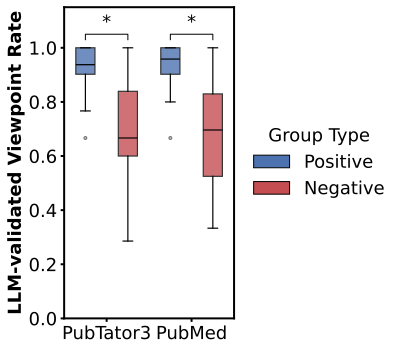

In [9]:
# Create boxplot comparison
data = [pubtator3_pos_rates, pubtator3_neg_rates, pubmed_pos_rates, pubmed_neg_rates]
labels = ["PubTator3", "PubTator3", "PubMed", "PubMed"]
pos_color = '#4C72B0'
neg_color = '#C44E52'
box_colors = [pos_color, neg_color, pos_color, neg_color]

fig, ax = plt.subplots(figsize=(7, 5.2))

box = ax.boxplot(
    data,
    patch_artist=True,
    tick_labels=labels,
    medianprops=dict(color='black', linewidth=1.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='gray', alpha=0.5)
)

# Set box colors
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.2)

# Set all elements to black
for element in ['whiskers', 'caps', 'medians']:
    for line in box[element]:
        line.set_color('black')
        line.set_linewidth(1.2)

for flier in box['fliers']:
    flier.set_markeredgecolor('black')
    flier.set_markerfacecolor('gray')

# Set spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2.0)

ax.xaxis.set_tick_params(width=2.0)
ax.yaxis.set_tick_params(width=2.0)

ax.set_xticks([1.5, 3.5])
ax.set_xticklabels(['PubTator3', 'PubMed'])
ax.set_ylabel('LLM-validated Viewpoint Rate', fontsize=fs_base-2, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.tick_params(axis='x', labelrotation=0, labelsize=fs_base-2, width=2.0)
ax.tick_params(axis='y', labelsize=fs_base-2, width=2.0)

# Add legend
from matplotlib.patches import Patch
group_legend = [
    Patch(facecolor=pos_color, edgecolor='black', label='Positive'),
    Patch(facecolor=neg_color, edgecolor='black', label='Negative')
]

ax.legend(
    handles=group_legend,
    title="Group Type",
    fontsize=fs_base-2,
    title_fontsize=fs_base-2,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Add significance bars
def add_significance_bar(ax, x1, x2, y, p_value, bar_height=0.02, text_offset=0.01):
    if p_value >= 0.05:
        return
    ax.plot([x1, x1, x2, x2], [y, y+bar_height, y+bar_height, y], lw=1, c='black')
    if p_value < 0.05:
        text = "*"
    ax.text((x1+x2)/2, y+bar_height+text_offset, text, ha='center', va='bottom', fontsize=fs_base-2)

add_significance_bar(ax, 1, 2, 1.03, p_val_pubtator)
add_significance_bar(ax, 3, 4, 1.03, p_val_pubmed)
add_significance_bar(ax, 1, 3, 1.10, p_val_pos)
add_significance_bar(ax, 2, 4, 1.10, p_val_neg)

plt.tight_layout(rect=(0, 0, 0.85, 1))
plt.savefig('boxplot_comparison.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()

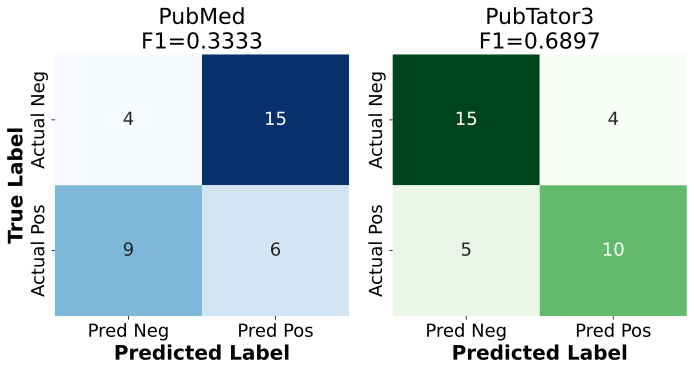

In [14]:
# Create confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5.5))
pubmed_cm = np.array([[4, 15],   # [[TN, FP],
                      [9, 6]])   #  [FN, TP]]
pubtator_cm = np.array([[15, 4],   # [[TN, FP],
                        [5, 10]])  #  [FN, TP]]
# Calculate metrics for visualization
precision_pubmed = pubmed_cm[1, 1] / (pubmed_cm[1, 1] + pubmed_cm[0, 1])
recall_pubmed = pubmed_cm[1, 1] / (pubmed_cm[1, 1] + pubmed_cm[1, 0])
precision_pubtator = pubtator_cm[1, 1] / (pubtator_cm[1, 1] + pubtator_cm[0, 1])
recall_pubtator = pubtator_cm[1, 1] / (pubtator_cm[1, 1] + pubtator_cm[1, 0])
f1_pubmed = 2 * precision_pubmed * recall_pubmed / (precision_pubmed + recall_pubmed)
f1_pubtator = 2 * precision_pubtator * recall_pubtator / (precision_pubtator + recall_pubtator)

# PubMed confusion matrix
sns.heatmap(pubmed_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'],
            ax=axes[0], annot_kws={'size': fs_base-2})
axes[0].set_title(f'PubMed\nF1={f1_pubmed:.4f}', fontsize=fs_base+2)
axes[0].set_xlabel('Predicted Label', fontsize=fs_base, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=fs_base, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=fs_base-2)

# PubTator3 confusion matrix
sns.heatmap(pubtator_cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Actual Neg', 'Actual Pos'],
            ax=axes[1], annot_kws={'size': fs_base-2})
axes[1].set_title(f'PubTator3\nF1={f1_pubtator:.4f}', fontsize=fs_base+2)
axes[1].set_xlabel('Predicted Label', fontsize=fs_base, fontweight='bold')
axes[1].set_ylabel('', fontsize=fs_base, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=fs_base-2)

plt.tight_layout()
plt.savefig('confusion_matrix_comparison.svg', format='svg', bbox_inches='tight', dpi=300)
plt.show()

## 7. Proteins with top ranked hypothesis.

In [ ]:
import json
import sys
from HGS_abduction import AI_Hypothesis
sys.path.append('../')

with open('../examples/10triplets_statistics.json', 'r') as f:
    triplets = json.load(f)


In [ ]:
import nest_asyncio
nest_asyncio.apply()
import asyncio
repeat_times = 3

for rp in range(repeat_times):
    print(f"Repeat {rp+1} of {repeat_times}")
    for triple in triplets:
        # Instantiate AI_Hypothesis for the given triple
        triplet = {}
        for i in triplets[triple]:
            if 'XAI' in i:
                continue
            elif 'Papers count' in i:
                continue 
            else:
                triplet[i] = triplets[triple][i]
        ai_scientist = AI_Hypothesis(
            triplet,
            num_hypothethesis=8,
            save_path=f"repeat{str(rp+5)}/{triplets[triple].get('cancer name')}_{triplets[triple].get('gene name')}_8",
            knowledge_path="../pubmed_abstract",
            chatModel='o3-mini',
            embeddingModel='text-embedding-3-small'
        )
        champion_hypothesis = asyncio.run(ai_scientist.internal_trial_system())
        print(f"Champion hypothesis for triple {triplets[triple].get('cancer name')}_{triplets[triple].get('gene name')}':\n{champion_hypothesis}\n")
        

In [17]:
repeat1 = pd.read_csv('../examples/repeat1/HypothesisScores.csv', index_col = 'gene name').sort_values(by='XAI rank', ascending=True)
repeat2 = pd.read_csv('../examples/repeat2/HypothesisScores.csv', index_col = 'gene name')
repeat3 = pd.read_csv('../examples/repeat3/HypothesisScores.csv', index_col = 'gene name').sort_values(by='XAI rank', ascending=True)

# harmonic mean -> rank
repeat1['har_mean_rank'] = repeat1['har_mean'].rank(method='max', ascending=False).astype(int)
repeat2['har_mean_rank'] = repeat2['har_mean'].rank(method='max', ascending=False).astype(int)
repeat3['har_mean_rank'] = repeat3['har_mean'].rank(method='max', ascending=False).astype(int)


df_OS = pd.DataFrame(index=repeat2.index)
df_OS['repeat1_rank'] = repeat1['har_mean_rank']
df_OS['repeat2_rank'] = repeat2['har_mean_rank']
df_OS['repeat3_rank'] = repeat3['har_mean_rank']
df_OS['repeat1_score'] = repeat1['har_mean']
df_OS['repeat2_score'] = repeat2['har_mean']
df_OS['repeat3_score'] = repeat3['har_mean']

# visualize the correlation
df_score = df_OS[['repeat1_score', 'repeat2_score', 'repeat3_score']]
df_rank = df_OS[['repeat1_rank', 'repeat2_rank', 'repeat3_rank']]
df_OS['mean'] = df_score.mean(axis=1)
df_OS['std'] = df_score.std(axis=1)
df_OS['mean_rank'] = df_rank.mean(axis=1)
df_OS['std_rank'] = df_rank.std(axis=1)

# visualize the correlation
df_OS.sort_values(by='mean_rank', ascending=False)

,repeat1_rank,repeat2_rank,repeat3_rank,repeat1_score,repeat2_score,repeat3_score,mean,std,mean_rank,std_rank
gene name,,,,,,,,,,
BANF1,30,29,29,0.000000,0.081191,0.048368,0.043186,0.040843,29.333333,0.577350
TSTD1,21,25,23,0.199916,0.243622,0.346718,0.263419,0.075377,23.000000,2.000000
PAPSS1,27,15,25,0.125159,0.403772,0.277614,0.268848,0.139513,22.333333,6.429101
HMGA1,22,30,14,0.195690,0.000000,0.447163,0.214284,0.224161,22.000000,8.000000
PARP9,25,20,20,0.134018,0.305641,0.370519,0.270060,0.122200,21.666667,2.886751
C4A,23,14,27,0.188494,0.423794,0.223015,0.278434,0.127063,21.333333,6.658328
AHNAK2,17,18,28,0.242632,0.328145,0.161280,0.244019,0.083441,21.000000,6.082763
RMDN1,29,4,30,0.100910,0.594790,0.000000,0.231900,0.318297,21.000000,14.730920
HDAC1,10,27,26,0.371787,0.210935,0.268368,0.283697,0.081514,21.000000,9.539392


In [18]:
# overall plasuability -> rank
repeat1['OP_rank'] = repeat1['OP'].rank(method='max', ascending=False).astype(int)
repeat2['OP_rank'] = repeat2['OP'].rank(method='max', ascending=False).astype(int)
repeat3['OP_rank'] = repeat3['OP'].rank(method='max', ascending=False).astype(int)


df_OP = pd.DataFrame(index=repeat2.index)
df_OP['repeat1'] = repeat1['OP_rank']
df_OP['repeat2'] = repeat2['OP_rank']
df_OP['repeat3'] = repeat3['OP_rank']
df_OP['repeat1_score'] = repeat1['OP']
df_OP['repeat2_score'] = repeat2['OP']
df_OP['repeat3_score'] = repeat3['OP']

# visualize the correlation
df_score = df_OP[['repeat1_score', 'repeat2_score', 'repeat3_score']]
df_rank = df_OP[['repeat1', 'repeat2', 'repeat3']]
df_OP['mean'] = df_score.mean(axis=1)
df_OP['std'] = df_score.std(axis=1)
df_OP['mean_rank'] = df_rank.mean(axis=1)
df_OP['std_rank'] = df_rank.std(axis=1)  
# visualize the correlation
df_OP['XAI rank'] = range(1, len(df_OP)+1)

In [19]:
# overall plausability ->rank
repeat1['ON_rank'] = repeat1['ON_norm'].rank(method='max', ascending=False).astype(int)
repeat2['ON_rank'] = repeat2['ON_norm'].rank(method='max', ascending=False).astype(int)
repeat3['ON_rank'] = repeat3['ON_norm'].rank(method='max', ascending=False).astype(int)

df_ON = pd.DataFrame(index=repeat2.index)
df_ON['repeat1'] = repeat1['ON_rank']
df_ON['repeat2'] = repeat2['ON_rank']
df_ON['repeat3'] = repeat3['ON_rank']
df_ON['repeat1_score'] = repeat1['ON_norm']
df_ON['repeat2_score'] = repeat2['ON_norm']
df_ON['repeat3_score'] = repeat3['ON_norm']


# visualize the correlation

df_score = df_ON[['repeat1_score', 'repeat2_score', 'repeat3_score']]
df_rank = df_ON[['repeat1', 'repeat2', 'repeat3']]
df_ON['mean'] = df_score.mean(axis=1)
df_ON['std'] = df_score.std(axis=1)
df_ON['mean_rank'] = df_rank.mean(axis=1)
df_ON['std_rank'] = df_rank.std(axis=1)

df_ON.sort_values(by='mean_rank', ascending=False)

# visualize the correlation


,repeat1,repeat2,repeat3,repeat1_score,repeat2_score,repeat3_score,mean,std,mean_rank,std_rank
gene name,,,,,,,,,,
BANF1,30,29,29,0.000000,0.042765,0.025094,0.022620,0.021490,29.333333,0.577350
HMGA1,23,30,22,0.112105,0.000000,0.336401,0.149502,0.171290,25.000000,4.358899
TSTD1,22,26,25,0.121151,0.175149,0.251992,0.182764,0.065753,24.333333,2.081666
C4A,24,21,27,0.110983,0.282689,0.182882,0.192184,0.086230,24.000000,3.000000
PAPSS1,27,18,26,0.069062,0.317128,0.237855,0.208015,0.126697,23.666667,4.932883
HDAC1,12,28,28,0.228341,0.127961,0.163422,0.173241,0.050905,22.666667,9.237604
RMDN1,29,7,30,0.054800,0.589671,0.000000,0.214824,0.325781,22.000000,13.000000
PARP9,25,23,17,0.083869,0.237513,0.484380,0.268588,0.202056,21.666667,4.163332
HDDC3,26,16,19,0.078530,0.343929,0.415578,0.279346,0.177563,20.333333,5.131601


Statistics from three repetition experiments (OS):
           repeat1_rank  repeat2_rank  repeat3_rank  repeat1_score  \
gene name                                                            
HDAC1                10            27            26       0.371787   
PAFAH1B3             24            19             4       0.159274   
RMDN1                29             4            30       0.100910   
PFKFB2               26             1            16       0.126091   
MAP3K2               19            22            13       0.213820   
AHNAK2               17            18            28       0.242632   
CIAO2A               14            24            18       0.272325   
PARP9                25            20            20       0.134018   
SRSF9                 6             6             5       0.459633   
DTX3L                18            21            12       0.242469   
SCO2                  8            17             2       0.411673   
EIF2B2               12            23  

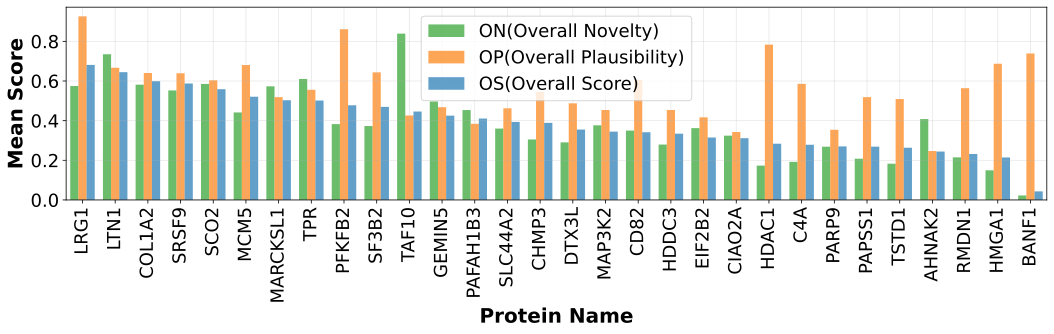

In [20]:
# 展示ON、OP、OS的top 20，横坐标是基因，一个基因对应三个不同颜色的柱状图，对应OS, OP, ON
# 不显示std，纵坐标从0开始

%config InlineBackend.figure_format = 'svg'
fs_base = 20

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': fs_base-2,               
    'axes.titlesize': fs_base+2,         
    'axes.labelsize': fs_base,            
    'xtick.labelsize': fs_base-2,
    'ytick.labelsize': fs_base-2,
    'legend.fontsize': fs_base-2,         # 图形标题大小
})


genes = df_OS.sort_values(by='mean', ascending=False).index.tolist()

# 取出每个基因的mean_rank
os_ranks = df_OS.loc[genes, 'mean']
op_ranks = df_OP.loc[genes, 'mean']
on_ranks = df_ON.loc[genes, 'mean']

x = np.arange(len(genes))  # 横坐标

width = 0.25  # 柱状图宽度

fig, ax = plt.subplots(figsize=(15, 5))

# 画三组柱状图（不显示std）
rects1 = ax.bar(x - width, on_ranks, width, label='ON(Overall Novelty)', alpha=0.7, color='#2ca02c')
rects2 = ax.bar(x, op_ranks, width, label='OP(Overall Plausibility)', alpha=0.7, color='#ff7f0e')
rects3 = ax.bar(x + width, os_ranks, width, label='OS(Overall Score)', alpha=0.7, color='#1f77b4')

ax.set_xlabel('Protein Name', fontweight='bold')
ax.set_ylabel('Mean Score', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(genes, rotation=90)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)  # 纵坐标从0开始

# 调整x轴范围，使第一个刻度靠近y轴
ax.set_xlim(-0.5, len(genes)-0.5)

plt.tight_layout()
plt.show()
# Print statistics
print("Statistics from three repetition experiments (OS):")
print(df_OS)
print(f"\nAverage ranking (OS): {df_OS['mean'].mean():.2f}")

print("\nStatistics from three repetition experiments (OP):")
print(df_OP)
print(f"\nAverage ranking (OP): {df_OP['mean'].mean():.2f}")

print("\nStatistics from three repetition experiments (ON):")
print(df_ON)
print(f"\nAverage ranking (ON): {df_ON['mean'].mean():.2f}")